# Final Project

Welcome to the final practical project for our course on [Data Science Bootcamp](https://open.hpi.de/courses/datascience2023). Throughout this project, you will go through the entire data science process, starting from data loading and cleaning, all the way to running a model and making predictions. This hands-on project will provide you with valuable experience and allow you to apply the concepts and techniques you've learned in the course. Get ready to dive into real-world data analysis and build your skills as a data scientist!


## Important Remarks:

 - The ultimate goal of this project is to conduct comprehensive data analysis and build 2 models using the provided datasets.
 - Code is not the only thing graded here. Well-written and understandable documentation of your code is to be expected
 - Clear reasoning behind your choices in every step of the notebook is important. Be it the choice of a data cleaning technique or selecting certain features in your analysis or the choice of your 2 models

# Importing packages


In [36]:
#Import Pandas library + Matplotlib for graphics
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset into data


In [37]:
#Read titanic.csv 
titanic = pd.read_csv("titanic.csv")

# Dataset overview and statistical summary


In [4]:
# Display the head of the dataset
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
#Display the info of the dataset
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1000 non-null   int64  
 1   Survived     1000 non-null   int64  
 2   Pclass       1000 non-null   int64  
 3   Name         1000 non-null   object 
 4   Sex          1000 non-null   object 
 5   Age          823 non-null    float64
 6   SibSp        1000 non-null   int64  
 7   Parch        1000 non-null   int64  
 8   Ticket       1000 non-null   object 
 9   Fare         1000 non-null   float64
 10  Cabin        299 non-null    object 
 11  Embarked     998 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 93.9+ KB


In [7]:
#Use the describe method to view the statistics of the dataset
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1000.000000,1000.000000,1000.000000,823.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,0.404000,2.274000,30.177606,0.716000,0.571000,56.732249
std,288.819436,0.490943,0.840018,15.138305,1.312656,1.046926,98.014902
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,250.750000,0.000000,1.000000,21.000000,0.000000,0.000000,8.050000
50%,500.500000,0.000000,3.000000,29.000000,0.000000,0.000000,17.600000
75%,750.250000,1.000000,3.000000,39.500000,1.000000,1.000000,52.000000
max,1000.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Data cleaning

In [8]:
#Check the null/missing values in dataset to see if we need replacing/ adding data
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          701
Embarked         2
dtype: int64

<bound method Series.mode of 0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
995    44.0
996    32.0
997    60.0
998    49.0
999    58.0
Name: Age, Length: 1000, dtype: float64>

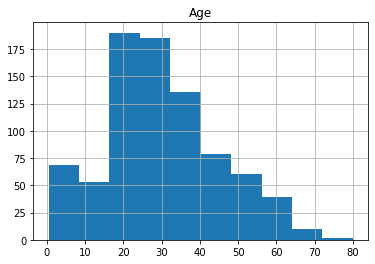

In [29]:
#As Age and Cabin are missing (177 times, 701 times) we can replace the age values: 
#Nominal/ categorical values -> replace with mode. (“How old are you” is used to collect nominal data.) 
#Cabin doesn't really get us additional values so we can leave it the way it is or even delete it. -> I will leave it as is.

#visualisation
titanic.hist(['Age'])

#find mode for column Age
titanic['Age'].mode

In [30]:
#fill in mode into missing age values
titanic["Age"].fillna("22.0")

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
995    44.0
996    32.0
997    60.0
998    49.0
999    58.0
Name: Age, Length: 1000, dtype: object

In [7]:
#check if mode changes -> it shouldn't and it doesn't
titanic['Age'].mode

<bound method Series.mode of 0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
995    44.0
996    32.0
997    60.0
998    49.0
999    58.0
Name: Age, Length: 1000, dtype: float64>

# EDA

In [3]:
#import seaborn for visualization
import seaborn as sns

In [ ]:
sns.pairplot(titanic, x_vars= ['Age','Fare','Pclass','Survived'], y_vars=['Age','Fare','Pclass','Survived'])

In [ ]:
#Correlation matrix for titanic dataset
plt.figure(figsize=(4,4),dpi=50)
plt.title('Correlation matrix for titanic dataset');
result=titanic.corr()
sns.heatmap(result, annot=True)

In [ ]:
#survival rate of passengers by sex
def get_survival_rates(titanic):
 
    resultF= titanic[(titanic["Sex"]=="female")&(titanic["Survived"]==1)].count()/titanic[(titanic["Sex"]=="female")].count()
    resultM= titanic[(titanic["Sex"]=="male")&(titanic["Survived"]==1)].count()/titanic[(titanic["Sex"]=="male")].count()
    d={'female':resultF["Survived"], 'male':resultM["Survived"],}
    result =pd.Series(data=d, index=['female','male'])   

    return result

get_survival_rates(titanic)

In [ ]:
#correlation between passenger age and fare paid
def get_age_fare_corr(titanic):

    result= titanic['Age'].corr(titanic['Fare'])
    
    return result

get_age_fare_corr(titanic)

# Data Processing and normalization

# Creating ML model 1

In [40]:
# Import necessary libraries
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
import pandas as pd

In [39]:
# Create X,y from dataset. 
# -> Find out if there's a relationship between Age and Fare  

df = pd.DataFrame(data=titanic)
#convert columns into series for reshaping
#Unfortunately, I used deprecated methods .ix -> doesn't work in this version of jupyter
serAge = df.ix[:,3]
serFare = serAge = df.ix[:,6]

X = serAge.reshape(1,-1)
y = serFare.reshape(1,-1)

#Create Linear Regression Object
model=LinearRegression()

AttributeError: 'Series' object has no attribute 'reshape'

## Prediction on Test data

In [31]:
#Fit the model 
model.fit(X,y)

ValueError: Expected 2D array, got 1D array instead:
array=[22.   38.   26.   35.   35.     nan 54.    2.   27.   14.    4.   58.
 20.   39.   14.   55.    2.     nan 31.     nan 35.   34.   15.   28.
  8.   38.     nan 19.     nan   nan 40.     nan   nan 66.   28.   42.
   nan 21.   18.   14.   40.   27.     nan  3.   19.     nan   nan   nan
   nan 18.    7.   21.   49.   29.   65.     nan 21.   28.5   5.   11.
 22.   38.   45.    4.     nan   nan 29.   19.   17.   26.   32.   16.
 21.   26.   32.   25.     nan   nan  0.83 30.   22.   29.     nan 28.
 17.   33.   16.     nan 23.   24.   29.   20.   46.   26.   59.     nan
 71.   23.   34.   34.   28.     nan 21.   33.   37.   28.   21.     nan
 38.     nan 47.   14.5  22.   20.   17.   21.   70.5  29.   24.    2.
 21.     nan 32.5  32.5  54.   12.     nan 24.     nan 45.   33.   20.
 47.   29.   25.   23.   19.   37.   16.   24.     nan 22.   24.   19.
 18.   19.   27.    9.   36.5  42.   51.   22.   55.5  40.5    nan 51.
 16.   30.  

## Model 1 Performance

In [33]:
# Print the accuracy score of the classifier
print(f"Accuracy using score function: {model.score(X, y)*100}%")

NotFittedError: This LinearRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

# Creating ML model 2

In [ ]:
#DecisionTree 

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(diabetes.data, diabetes.target, test_size=0.2, random_state=42)

# Create a decision tree regressor with a maximum depth of 3
DTR = DecisionTreeRegressor(max_depth=5)

# Train the regressor on the training set
DTR.fit(X_train, y_train)



In [ ]:
# Do the split with 75% train and 25% test. replace the string with the actual input
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    stratify=y,  # Leave this unchanged 
                                                    random_state=42) # Leave this unchanged
# Create a decision tree classifier with a maximum depth of 3
DTC = DecisionTreeClassifier(max_depth=3)

## Prediction on Test data

In [ ]:
# Predict the target values for the testing set
y_pred = DTR.predict(X_test)

## ## Model 2 Performance

In [ ]:
# Print the mean squared error of the regressor
print("Mean Absolute Error:", metrics.mean_absolute_error(y_test, y_pred))

# Report and insight from your analysis

Reshaping my data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) as mentioned in the error message didn't work. I tried converting the series to arrays but unfortunately used the deprecated method .ix -> doesn't work for this version of jupyter notebook.